# 04.4 — Hypothesis 4

## Emotional condition × cognitive load

### Hypothesis

The effect of emotional condition on working-memory performance varies
according to cognitive load across the 1-back, 2-back, 3-back, and
4-back levels.

### Primary predictors

1. Emotional condition
   - Neutral
   - Positive
   - Negative

2. Cognitive load
   - 1-back
   - 2-back
   - 3-back
   - 4-back

3. Emotional condition × cognitive-load interaction

### Primary outcomes

1. Trial-level response accuracy.
2. Reaction time among valid correct-response trials.

### Analytical strategy

The primary inferential test is the interaction between emotional
condition and n-back level.

Accuracy is analyzed using a binomial GEE model.

Reaction time is analyzed using a linear mixed-effects model with
log-transformed reaction time and participant-specific random intercepts.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from src import config as cfg
from src.utils import initialize_project

initialize_project()


## 3. Carregar os dados

In [2]:
analysis = pd.read_csv(
    cfg.ANALYSIS_DATASET_FILE,
    low_memory=False,
)

print(
    f"Dataset shape: {analysis.shape}"
)

print(
    f"Participants: "
    f"{analysis['participant_id'].nunique()}"
)

Dataset shape: (17820, 63)
Participants: 23


## 4. Selecionar dados H4

In [3]:
h4_data = (
    analysis.loc[
        analysis[
            "emotion_condition"
        ].isin(
            [
                "Neutral",
                "Positive",
                "Negative",
            ]
        )
    ]
    .copy()
)

In [4]:
assert set(
    h4_data[
        "emotion_condition"
    ].dropna().unique()
) == {
    "Neutral",
    "Positive",
    "Negative",
}

In [5]:
assert set(
    h4_data[
        "nback_level"
    ].dropna().unique()
) == {
    1,
    2,
    3,
    4,
}

## 5. Auditoria da amostra

In [6]:
h4_sample = (
    h4_data
    .groupby(
        [
            "emotion_condition",
            "nback_level",
        ]
    )
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "accuracy",
            "size",
        ),
        valid_accuracy=(
            "accuracy",
            "count",
        ),
    )
    .reset_index()
)

h4_sample

,emotion_condition,nback_level,participants,trials,valid_accuracy
0,Negative,1,22,1320,1320
1,Negative,2,22,1980,1980
2,Negative,3,22,1320,1320
3,Negative,4,22,1320,1320
4,Neutral,1,23,1320,1320
5,Neutral,2,23,1980,1980
6,Neutral,3,23,1320,1320
7,Neutral,4,23,1320,1320
8,Positive,1,22,1320,1320
9,Positive,2,22,1980,1980


## 6. Accuracy descritiva

In [7]:
accuracy_summary_h4 = (
    h4_data
    .groupby(
        [
            "emotion_condition",
            "nback_level",
        ]
    )
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "accuracy",
            "size",
        ),
        correct=(
            "accuracy",
            "sum",
        ),
        accuracy_mean=(
            "accuracy",
            "mean",
        ),
        accuracy_sd=(
            "accuracy",
            "std",
        ),
        accuracy_median=(
            "accuracy",
            "median",
        ),
    )
    .reset_index()
)

accuracy_summary_h4

,emotion_condition,nback_level,participants,trials,correct,accuracy_mean,accuracy_sd,accuracy_median
0,Negative,1,22,1320,1289,0.976515,0.151495,1.0
1,Negative,2,22,1980,1764,0.890909,0.311832,1.0
2,Negative,3,22,1320,1018,0.771212,0.420212,1.0
3,Negative,4,22,1320,907,0.687121,0.463841,1.0
4,Neutral,1,23,1320,1301,0.985606,0.119153,1.0
5,Neutral,2,23,1980,1774,0.895960,0.305390,1.0
6,Neutral,3,23,1320,990,0.750000,0.433177,1.0
7,Neutral,4,23,1320,984,0.745455,0.435770,1.0
8,Positive,1,22,1320,1309,0.991667,0.090940,1.0
9,Positive,2,22,1980,1779,0.898485,0.302086,1.0


## 7. Accuracy em formato pivot

In [8]:
accuracy_matrix_h4 = (
    accuracy_summary_h4
    .pivot(
        index="nback_level",
        columns="emotion_condition",
        values="accuracy_mean",
    )
)

accuracy_matrix_h4

emotion_condition,Negative,Neutral,Positive
nback_level,,,
1,0.976515,0.985606,0.991667
2,0.890909,0.895960,0.898485
3,0.771212,0.750000,0.771970
4,0.687121,0.745455,0.718182


## 8. Figura principal de accuracy

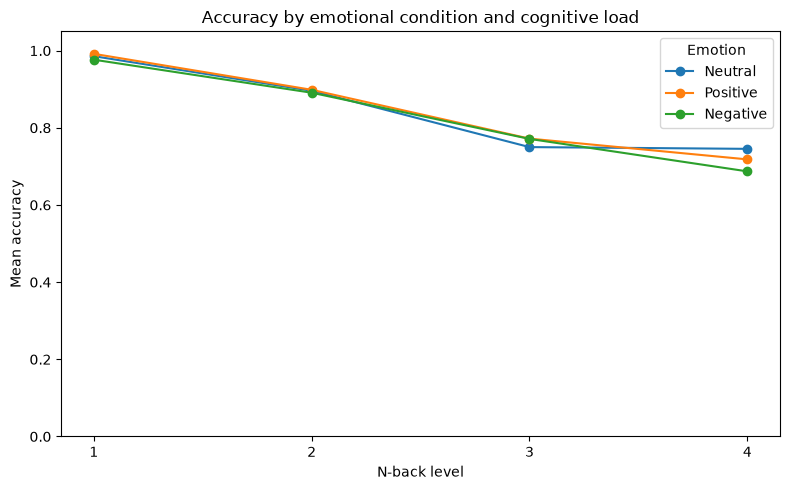

In [9]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for condition in [
    "Neutral",
    "Positive",
    "Negative",
]:

    subset = (
        accuracy_summary_h4.loc[
            accuracy_summary_h4[
                "emotion_condition"
            ] == condition
        ]
        .sort_values(
            "nback_level"
        )
    )

    ax.plot(
        subset[
            "nback_level"
        ],
        subset[
            "accuracy_mean"
        ],
        marker="o",
        label=condition,
    )

ax.set_xlabel(
    "N-back level"
)

ax.set_ylabel(
    "Mean accuracy"
)

ax.set_xticks(
    [1, 2, 3, 4]
)

ax.set_ylim(
    0,
    1.05,
)

ax.set_title(
    "Accuracy by emotional condition and cognitive load"
)

ax.legend(
    title="Emotion"
)

fig.tight_layout()

plt.show()

## 9. Accuracy — modelo principal

In [10]:
accuracy_formula_h4 = (
    "accuracy ~ "
    "C(emotion_condition, Treatment(reference='Neutral')) "
    "* C(nback_level, Treatment(reference=1))"
)

**Modelo GEE:**

In [11]:
accuracy_model_h4 = (
    smf.gee(
        formula=(
            accuracy_formula_h4
        ),
        groups="participant_id",
        data=h4_data,
        family=(
            sm.families.Binomial()
        ),
        cov_struct=(
            sm.cov_struct.Exchangeable()
        ),
    )
    .fit()
)

print(
    accuracy_model_h4.summary()
)

                               GEE Regression Results                              
Dep. Variable:                    accuracy   No. Observations:                17820
Model:                                 GEE   No. clusters:                       23
Method:                        Generalized   Min. cluster size:                 405
                      Estimating Equations   Max. cluster size:                 810
Family:                           Binomial   Mean cluster size:               774.8
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Fri, 07 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         16:14:22
                                                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

## 10. Wald test global

<br>

Este é um dos resultados mais importantes da H4:

In [12]:
accuracy_wald_h4 = (
    accuracy_model_h4
    .wald_test_terms()
)

accuracy_wald_h4

C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                                                                                               chi2                   P>chi2  df constraint
Intercept                                                                                     [[504.0241032030169]]  1.2659414019776722e-111              1
C(emotion_condition, Treatment(reference='Neutral'))                                          [[8.106658589273454]]     0.017364466870547927              2
C(nback_level, Treatment(reference=1))                                                        [[276.7181705030194]]   1.0862572329979642e-59              3
C(emotion_condition, Treatment(reference='Neutral')):C(nback_level, Treatment(reference=1))  [[29.925363519043948]]     4.06137097683631e-05              6

## 11. Extrair todos os coeficientes

In [13]:
accuracy_ci_h4 = (
    accuracy_model_h4
    .conf_int()
)

accuracy_model_table_h4 = (
    pd.DataFrame(
        {
            "term":
                accuracy_model_h4.params.index,

            "beta":
                accuracy_model_h4.params.values,

            "se":
                accuracy_model_h4.bse.values,

            "z":
                accuracy_model_h4.tvalues.values,

            "p":
                accuracy_model_h4.pvalues.values,

            "ci_low":
                accuracy_ci_h4.iloc[
                    :, 0
                ].values,

            "ci_high":
                accuracy_ci_h4.iloc[
                    :, 1
                ].values,
        }
    )
)

accuracy_model_table_h4[
    "odds_ratio"
] = np.exp(
    accuracy_model_table_h4[
        "beta"
    ]
)

accuracy_model_table_h4[
    "or_ci_low"
] = np.exp(
    accuracy_model_table_h4[
        "ci_low"
    ]
)

accuracy_model_table_h4[
    "or_ci_high"
] = np.exp(
    accuracy_model_table_h4[
        "ci_high"
    ]
)

accuracy_model_table_h4

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,Intercept,4.185505,0.186433,22.450481,1.265941e-111,3.820104,4.550907,65.726715,45.608949,94.718278
1,"C(emotion_condition, Treatment(reference='Neut...",-0.477509,0.224723,-2.124876,3.359692e-02,-0.917958,-0.037060,0.620327,0.399334,0.963619
2,"C(emotion_condition, Treatment(reference='Neut...",0.519051,0.334220,1.553021,1.204181e-01,-0.136008,1.174110,1.680431,0.872835,3.235261
3,"C(nback_level, Treatment(reference=1))[T.2]",-2.048363,0.177849,-11.517409,1.078046e-30,-2.396942,-1.699785,0.128946,0.090996,0.182723
4,"C(nback_level, Treatment(reference=1))[T.3]",-3.098156,0.194307,-15.944645,3.103971e-57,-3.478991,-2.717322,0.045132,0.030839,0.066051
5,"C(nback_level, Treatment(reference=1))[T.4]",-3.122187,0.193655,-16.122402,1.775719e-58,-3.501744,-2.742630,0.044061,0.030145,0.064401
6,"C(emotion_condition, Treatment(reference='Neut...",0.430888,0.219710,1.961168,4.985941e-02,0.000265,0.861512,1.538623,1.000265,2.366736
7,"C(emotion_condition, Treatment(reference='Neut...",-0.498141,0.346193,-1.438910,1.501759e-01,-1.176666,0.180385,0.607659,0.308305,1.197679
8,"C(emotion_condition, Treatment(reference='Neut...",0.598248,0.241644,2.475739,1.329607e-02,0.124634,1.071862,1.818929,1.132734,2.920812
9,"C(emotion_condition, Treatment(reference='Neut...",-0.403093,0.367762,-1.096071,2.730477e-01,-1.123893,0.317707,0.668250,0.325012,1.373973


## 12. Identificar termos de interação

In [14]:
accuracy_interactions_h4 = (
    accuracy_model_table_h4.loc[
        accuracy_model_table_h4[
            "term"
        ].str.contains(
            ":",
            regex=False,
        )
    ]
    .copy()
)

accuracy_interactions_h4

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
6,"C(emotion_condition, Treatment(reference='Neut...",0.430888,0.219710,1.961168,0.049859,0.000265,0.861512,1.538623,1.000265,2.366736
7,"C(emotion_condition, Treatment(reference='Neut...",-0.498141,0.346193,-1.438910,0.150176,-1.176666,0.180385,0.607659,0.308305,1.197679
8,"C(emotion_condition, Treatment(reference='Neut...",0.598248,0.241644,2.475739,0.013296,0.124634,1.071862,1.818929,1.132734,2.920812
9,"C(emotion_condition, Treatment(reference='Neut...",-0.403093,0.367762,-1.096071,0.273048,-1.123893,0.317707,0.668250,0.325012,1.373973
10,"C(emotion_condition, Treatment(reference='Neut...",0.194471,0.265496,0.732482,0.463874,-0.325891,0.714833,1.214668,0.721884,2.043846
11,"C(emotion_condition, Treatment(reference='Neut...",-0.661979,0.370158,-1.788371,0.073716,-1.387475,0.063517,0.515829,0.249705,1.065577


## 13. Contrastes simples por nível

<br>

Mesmo que a interação global seja significativa, precisamos interpretar:

Positive vs Neutral
Negative vs Neutral
Positive vs Negative

em cada nível:

1-back
2-back
3-back
4-back

A forma mais transparente é ajustar um GEE separado por nível.

In [15]:
def fit_accuracy_by_load(
    data: pd.DataFrame,
    level: int,
    reference: str = "Neutral",
):
    """
    Fit an emotion-condition GEE within one n-back level.
    """

    subset = (
        data.loc[
            data[
                "nback_level"
            ] == level
        ]
        .copy()
    )

    formula = (
        "accuracy ~ "
        "C(emotion_condition, "
        f"Treatment(reference='{reference}'))"
    )

    model = (
        smf.gee(
            formula=formula,
            groups="participant_id",
            data=subset,
            family=(
                sm.families.Binomial()
            ),
            cov_struct=(
                sm.cov_struct.Exchangeable()
            ),
        )
        .fit()
    )

    return model

## 14. Positive/Negative vs Neutral por carga

In [16]:
accuracy_simple_effects = []

for level in [1, 2, 3, 4]:

    result = fit_accuracy_by_load(
        h4_data,
        level=level,
        reference="Neutral",
    )

    ci = result.conf_int()

    table = pd.DataFrame(
        {
            "term": result.params.index,
            "beta": result.params.values,
            "se": result.bse.values,
            "z": result.tvalues.values,
            "p": result.pvalues.values,
            "ci_low": ci.iloc[:, 0].values,
            "ci_high": ci.iloc[:, 1].values,
        }
    )

    table["odds_ratio"] = np.exp(table["beta"])
    table["or_ci_low"] = np.exp(table["ci_low"])
    table["or_ci_high"] = np.exp(table["ci_high"])
    table["nback_level"] = level

    table = table.loc[
        table["term"].str.contains("emotion_condition", regex=False)
    ].copy()

    table["contrast"] = np.where(
        table["term"].str.contains("Positive", regex=False),
        "Positive vs Neutral",
        "Negative vs Neutral",
    )

    accuracy_simple_effects.append(table)


In [17]:
accuracy_simple_effects_h4 = (
    pd.concat(
        accuracy_simple_effects,
        ignore_index=True,
    )
)

accuracy_simple_effects_h4

,term,beta,se,z,p,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high,nback_level,contrast
0,"C(emotion_condition, Treatment(reference='Neut...",-0.505414,0.225650,-2.239810,0.025103,-0.947680,-0.063147,0.603256,0.387639,0.938805,1,Negative vs Neutral
1,"C(emotion_condition, Treatment(reference='Neut...",0.562813,0.358955,1.567923,0.116899,-0.140725,1.266352,1.755605,0.868728,3.547885,1,Positive vs Neutral
2,"C(emotion_condition, Treatment(reference='Neut...",-0.049358,0.109713,-0.449883,0.652795,-0.264392,0.165676,0.951840,0.767672,1.180191,2,Negative vs Neutral
3,"C(emotion_condition, Treatment(reference='Neut...",0.023699,0.072276,0.327899,0.742988,-0.117959,0.165357,1.023982,0.888733,1.179815,2,Positive vs Neutral
4,"C(emotion_condition, Treatment(reference='Neut...",0.120714,0.102877,1.173375,0.240646,-0.080922,0.322350,1.128302,0.922265,1.380367,3,Negative vs Neutral
5,"C(emotion_condition, Treatment(reference='Neut...",0.115519,0.092453,1.249495,0.211484,-0.065685,0.296724,1.122456,0.936426,1.345443,3,Positive vs Neutral
6,"C(emotion_condition, Treatment(reference='Neut...",-0.277556,0.103168,-2.690329,0.007138,-0.479762,-0.075350,0.757633,0.618931,0.927418,4,Negative vs Neutral
7,"C(emotion_condition, Treatment(reference='Neut...",-0.147823,0.106845,-1.383525,0.166504,-0.357236,0.061590,0.862584,0.699607,1.063526,4,Positive vs Neutral


## 15. Positive vs Negative por carga

In [18]:
accuracy_positive_negative = []

for level in [1, 2, 3, 4]:

    result = fit_accuracy_by_load(
        h4_data,
        level=level,
        reference="Negative",
    )

    ci = result.conf_int()

    table = pd.DataFrame(
        {
            "term": result.params.index,
            "beta": result.params.values,
            "se": result.bse.values,
            "z": result.tvalues.values,
            "p": result.pvalues.values,
            "ci_low": ci.iloc[:, 0].values,
            "ci_high": ci.iloc[:, 1].values,
        }
    )

    table["odds_ratio"] = np.exp(table["beta"])
    table["or_ci_low"] = np.exp(table["ci_low"])
    table["or_ci_high"] = np.exp(table["ci_high"])
    table["nback_level"] = level

    table = table.loc[
        table["term"].str.contains("Positive", regex=False)
    ].copy()

    table["contrast"] = "Positive vs Negative"

    accuracy_positive_negative.append(table)


In [19]:
accuracy_positive_negative_h4 = pd.concat(
    accuracy_positive_negative,
    ignore_index=True,
)

accuracy_all_simple_effects_h4 = pd.concat(
    [
        accuracy_simple_effects_h4,
        accuracy_positive_negative_h4,
    ],
    ignore_index=True,
)

accuracy_all_simple_effects_h4[
    [
        "nback_level",
        "contrast",
        "odds_ratio",
        "or_ci_low",
        "or_ci_high",
        "p",
    ]
].sort_values([
    "nback_level",
    "contrast",
])


,nback_level,contrast,odds_ratio,or_ci_low,or_ci_high,p
0,1,Negative vs Neutral,0.603256,0.387639,0.938805,0.025103
8,1,Positive vs Negative,2.910215,1.381974,6.128442,0.004933
1,1,Positive vs Neutral,1.755605,0.868728,3.547885,0.116899
2,2,Negative vs Neutral,0.951840,0.767672,1.180191,0.652795
9,2,Positive vs Negative,1.075792,0.856300,1.351546,0.530333
3,2,Positive vs Neutral,1.023982,0.888733,1.179815,0.742988
4,3,Negative vs Neutral,1.128302,0.922265,1.380367,0.240646
10,3,Positive vs Negative,0.994819,0.815322,1.213833,0.959194
5,3,Positive vs Neutral,1.122456,0.936426,1.345443,0.211484
6,4,Negative vs Neutral,0.757633,0.618931,0.927418,0.007138


# Reaction Time

## 16. Criar base de RT

In [20]:
rt_h4 = (
    h4_data.loc[
        (
            h4_data[
                "accuracy"
            ] == 1
        )
        &
        (
            h4_data[
                "rt_valid"
            ] == True
        )
    ]
    .copy()
)

rt_h4[
    "log_rt"
] = np.log(
    rt_h4[
        "reaction_time_ms"
    ]
)

print(
    "RT observations:",
    len(rt_h4),
)

print(
    "Participants:",
    rt_h4[
        "participant_id"
    ].nunique(),
)

RT observations: 14184
Participants: 23


## 17. RT descritivo condition × load

In [21]:
rt_summary_h4 = (
    rt_h4
    .groupby(
        [
            "emotion_condition",
            "nback_level",
        ]
    )
    .agg(
        participants=(
            "participant_id",
            "nunique",
        ),
        trials=(
            "reaction_time_ms",
            "size",
        ),
        mean_rt=(
            "reaction_time_ms",
            "mean",
        ),
        sd_rt=(
            "reaction_time_ms",
            "std",
        ),
        median_rt=(
            "reaction_time_ms",
            "median",
        ),
        mean_log_rt=(
            "log_rt",
            "mean",
        ),
    )
    .reset_index()
)

rt_summary_h4

,emotion_condition,nback_level,participants,trials,mean_rt,sd_rt,median_rt,mean_log_rt
0,Negative,1,22,1191,487.142737,403.111680,347.0,5.965759
1,Negative,2,22,1680,800.847024,752.956898,500.5,6.335615
2,Negative,3,22,977,845.422723,858.590087,451.0,6.341394
3,Negative,4,22,856,853.436916,862.377823,483.5,6.368341
4,Neutral,1,23,1244,643.462219,555.725976,437.5,6.191415
5,Neutral,2,23,1709,1036.537156,900.367118,720.0,6.609637
6,Neutral,3,23,943,1172.933192,1007.663048,829.0,6.692841
7,Neutral,4,23,933,1060.720257,1018.840957,661.0,6.575908
8,Positive,1,22,1166,535.903087,573.714798,331.0,5.956003
9,Positive,2,22,1653,821.819117,817.704169,475.0,6.318989


## 18. Figura RT × cognitive load

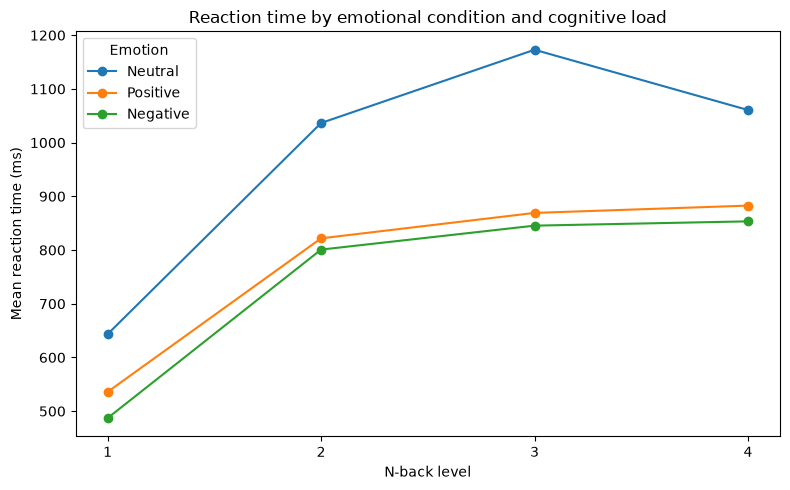

In [22]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

for condition in [
    "Neutral",
    "Positive",
    "Negative",
]:

    subset = (
        rt_summary_h4.loc[
            rt_summary_h4[
                "emotion_condition"
            ] == condition
        ]
        .sort_values(
            "nback_level"
        )
    )

    ax.plot(
        subset[
            "nback_level"
        ],
        subset[
            "mean_rt"
        ],
        marker="o",
        label=condition,
    )

ax.set_xlabel(
    "N-back level"
)

ax.set_ylabel(
    "Mean reaction time (ms)"
)

ax.set_xticks(
    [1, 2, 3, 4]
)

ax.set_title(
    "Reaction time by emotional condition and cognitive load"
)

ax.legend(
    title="Emotion"
)

fig.tight_layout()

plt.show()

## 19. Mixed model principal de RT

In [23]:
rt_formula_h4 = (
    "log_rt ~ "
    "C(emotion_condition, Treatment(reference='Neutral')) "
    "* C(nback_level, Treatment(reference=1))"
)

In [24]:
rt_model_h4 = (
    smf.mixedlm(
        formula=(
            rt_formula_h4
        ),
        data=rt_h4,
        groups=rt_h4[
            "participant_id"
        ],
    )
)

In [25]:
rt_result_h4 = (
    rt_model_h4.fit(
        reml=False
    )
)

print(
    rt_result_h4.summary()
)

                                                         Mixed Linear Model Regression Results
Model:                                            MixedLM                                Dependent Variable:                                log_rt     
No. Observations:                                 14184                                  Method:                                            ML         
No. Groups:                                       23                                     Scale:                                             0.5224     
Min. group size:                                  292                                    Log-Likelihood:                                    -15580.3227
Max. group size:                                  723                                    Converged:                                         Yes        
Mean group size:                                  616.7                                                                                          

## 20. RT model table

In [26]:
rt_ci_h4 = (
    rt_result_h4
    .conf_int()
)

rt_model_table_h4 = (
    pd.DataFrame(
        {
            "term":
                rt_result_h4.params.index,

            "beta":
                rt_result_h4.params.values,

            "se":
                rt_result_h4.bse.values,

            "z":
                rt_result_h4.tvalues.values,

            "p":
                rt_result_h4.pvalues.values,

            "ci_low":
                rt_ci_h4.iloc[
                    :, 0
                ].values,

            "ci_high":
                rt_ci_h4.iloc[
                    :, 1
                ].values,
        }
    )
)

In [27]:
rt_model_table_h4[
    "percent_change"
] = (
    np.exp(
        rt_model_table_h4[
            "beta"
        ]
    )
    - 1
) * 100

In [28]:
rt_model_table_h4[
    "percent_ci_low"
] = (
    np.exp(
        rt_model_table_h4[
            "ci_low"
        ]
    )
    - 1
) * 100

rt_model_table_h4[
    "percent_ci_high"
] = (
    np.exp(
        rt_model_table_h4[
            "ci_high"
        ]
    )
    - 1
) * 100

## 21. Termos de interação RT

In [29]:
rt_interactions_h4 = (
    rt_model_table_h4.loc[
        rt_model_table_h4[
            "term"
        ].str.contains(
            ":",
            regex=False,
        )
    ]
    .copy()
)

rt_interactions_h4

,term,beta,se,z,p,ci_low,ci_high,percent_change,percent_ci_low,percent_ci_high
6,"C(emotion_condition, Treatment(reference='Neut...",-0.055442,0.038413,-1.443320,0.148930,-0.130730,0.019846,-5.393326,-12.254546,2.004404
7,"C(emotion_condition, Treatment(reference='Neut...",-0.064751,0.038600,-1.677497,0.093445,-0.140405,0.010903,-6.269920,-13.099397,1.096282
8,"C(emotion_condition, Treatment(reference='Neut...",-0.112303,0.044137,-2.544422,0.010946,-0.198809,-0.025796,-10.622619,-18.029356,-2.546622
9,"C(emotion_condition, Treatment(reference='Neut...",-0.102572,0.044346,-2.312972,0.020724,-0.189489,-0.015655,-9.748660,-17.261809,-1.553271
10,"C(emotion_condition, Treatment(reference='Neut...",0.010154,0.045056,0.225371,0.821691,-0.078154,0.098463,1.020610,-7.517827,10.347360
11,"C(emotion_condition, Treatment(reference='Neut...",0.006099,0.045044,0.135407,0.892290,-0.082185,0.094384,0.611791,-7.889885,9.898165


## 22. Simple effects de RT

In [30]:
def fit_rt_by_load(
    data: pd.DataFrame,
    level: int,
    reference: str = "Neutral",
):
    """
    Fit an emotion-condition mixed model within one n-back level.
    """

    subset = (
        data.loc[
            data[
                "nback_level"
            ] == level
        ]
        .copy()
    )

    formula = (
        "log_rt ~ "
        "C(emotion_condition, "
        f"Treatment(reference='{reference}'))"
    )

    model = (
        smf.mixedlm(
            formula=formula,
            data=subset,
            groups=subset[
                "participant_id"
            ],
        )
        .fit(
            reml=False
        )
    )

    return model

## 23. Positive/Negative vs Neutral por nível

In [31]:
rt_simple_effects = []

for level in [1, 2, 3, 4]:

    result = fit_rt_by_load(
        rt_h4,
        level=level,
        reference="Neutral",
    )

    ci = result.conf_int()

    table = pd.DataFrame(
        {
            "term": result.params.index,
            "beta": result.params.values,
            "se": result.bse.values,
            "z": result.tvalues.values,
            "p": result.pvalues.values,
            "ci_low": ci.iloc[:, 0].values,
            "ci_high": ci.iloc[:, 1].values,
        }
    )

    table["percent_change"] = (np.exp(table["beta"]) - 1) * 100
    table["percent_ci_low"] = (np.exp(table["ci_low"]) - 1) * 100
    table["percent_ci_high"] = (np.exp(table["ci_high"]) - 1) * 100
    table["nback_level"] = level

    table = table.loc[
        table["term"].str.contains("emotion_condition", regex=False)
    ].copy()

    table["contrast"] = np.where(
        table["term"].str.contains("Positive", regex=False),
        "Positive vs Neutral",
        "Negative vs Neutral",
    )

    rt_simple_effects.append(table)


C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [32]:
rt_simple_effects_h4 = (
    pd.concat(
        rt_simple_effects,
        ignore_index=True,
    )
)

rt_simple_effects_h4

,term,beta,se,z,p,ci_low,ci_high,percent_change,percent_ci_low,percent_ci_high,nback_level,contrast
0,"C(emotion_condition, Treatment(reference='Neut...",-0.218359,0.025574,-8.538428,1.360607e-17,-0.268482,-0.168235,-19.616298,-23.546095,-15.484507,1,Negative vs Neutral
1,"C(emotion_condition, Treatment(reference='Neut...",-0.259253,0.025725,-10.077710,6.932275e-24,-0.309674,-0.208832,-22.837250,-26.631409,-18.846881,1,Positive vs Neutral
2,"C(emotion_condition, Treatment(reference='Neut...",-0.284478,0.024868,-11.439374,2.657967e-30,-0.333219,-0.235737,-24.759292,-28.338658,-21.001143,2,Negative vs Neutral
3,"C(emotion_condition, Treatment(reference='Neut...",-0.313385,0.024906,-12.582567,2.633304e-36,-0.362200,-0.264569,-26.903140,-30.385699,-23.246362,2,Positive vs Neutral
4,"C(emotion_condition, Treatment(reference='Neut...",-0.346849,0.034264,-10.122833,4.375618e-24,-0.414005,-0.279693,-29.308789,-33.900247,-24.398397,3,Negative vs Neutral
5,"C(emotion_condition, Treatment(reference='Neut...",-0.347325,0.034276,-10.133150,3.937548e-24,-0.414505,-0.280145,-29.342440,-33.933279,-24.432593,3,Positive vs Neutral
6,"C(emotion_condition, Treatment(reference='Neut...",-0.222244,0.035949,-6.182180,6.322241e-10,-0.292703,-0.151785,-19.928012,-25.375637,-14.082708,4,Negative vs Neutral
7,"C(emotion_condition, Treatment(reference='Neut...",-0.243088,0.035808,-6.788739,1.131182e-11,-0.313270,-0.172907,-21.579776,-26.894743,-15.878395,4,Positive vs Neutral


## 24. Positive vs Negative RT

In [33]:
reference="Negative"

In [34]:
rt_positive_negative = []

for level in [1, 2, 3, 4]:

    result = fit_rt_by_load(
        rt_h4,
        level=level,
        reference="Negative",
    )

    ci = result.conf_int()

    table = pd.DataFrame(
        {
            "term": result.params.index,
            "beta": result.params.values,
            "se": result.bse.values,
            "z": result.tvalues.values,
            "p": result.pvalues.values,
            "ci_low": ci.iloc[:, 0].values,
            "ci_high": ci.iloc[:, 1].values,
        }
    )

    table["percent_change"] = (np.exp(table["beta"]) - 1) * 100
    table["percent_ci_low"] = (np.exp(table["ci_low"]) - 1) * 100
    table["percent_ci_high"] = (np.exp(table["ci_high"]) - 1) * 100
    table["nback_level"] = level

    table = table.loc[
        table["term"].str.contains("Positive", regex=False)
    ].copy()

    table["contrast"] = "Positive vs Negative"

    rt_positive_negative.append(table)


C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\L

In [35]:
rt_positive_negative_h4 = (
    pd.concat(
        rt_positive_negative,
        ignore_index=True,
    )
)

rt_positive_negative_h4

,term,beta,se,z,p,ci_low,ci_high,percent_change,percent_ci_low,percent_ci_high,nback_level,contrast
0,"C(emotion_condition, Treatment(reference='Nega...",-0.040895,0.026296,-1.555157,0.119909,-0.092434,0.010645,-4.006971,-8.829068,1.070171,1,Positive vs Negative
1,"C(emotion_condition, Treatment(reference='Nega...",-0.028907,0.025355,-1.140099,0.254245,-0.078602,0.020788,-2.849319,-7.559179,2.100508,2,Positive vs Negative
2,"C(emotion_condition, Treatment(reference='Nega...",-0.000476,0.034325,-0.013871,0.988933,-0.067753,0.066801,-0.047602,-6.550855,6.908221,3,Positive vs Negative
3,"C(emotion_condition, Treatment(reference='Nega...",-0.020844,0.036927,-0.564476,0.572430,-0.093219,0.051531,-2.062848,-8.900617,5.288151,4,Positive vs Negative


In [36]:
rt_all_simple_effects_h4 = (
    pd.concat(
        [
            rt_simple_effects_h4,
            rt_positive_negative_h4,
        ],
        ignore_index=True,
    )
)

In [37]:
rt_all_simple_effects_h4[
    [
        "nback_level",
        "contrast",
        "beta",
        "percent_change",
        "percent_ci_low",
        "percent_ci_high",
        "p",
    ]
].sort_values(
    [
        "nback_level",
        "contrast",
    ]
)

,nback_level,contrast,beta,percent_change,percent_ci_low,percent_ci_high,p
0,1,Negative vs Neutral,-0.218359,-19.616298,-23.546095,-15.484507,1.360607e-17
8,1,Positive vs Negative,-0.040895,-4.006971,-8.829068,1.070171,1.199087e-01
1,1,Positive vs Neutral,-0.259253,-22.837250,-26.631409,-18.846881,6.932275e-24
2,2,Negative vs Neutral,-0.284478,-24.759292,-28.338658,-21.001143,2.657967e-30
9,2,Positive vs Negative,-0.028907,-2.849319,-7.559179,2.100508,2.542449e-01
3,2,Positive vs Neutral,-0.313385,-26.903140,-30.385699,-23.246362,2.633304e-36
4,3,Negative vs Neutral,-0.346849,-29.308789,-33.900247,-24.398397,4.375618e-24
10,3,Positive vs Negative,-0.000476,-0.047602,-6.550855,6.908221,9.889327e-01
5,3,Positive vs Neutral,-0.347325,-29.342440,-33.933279,-24.432593,3.937548e-24
6,4,Negative vs Neutral,-0.222244,-19.928012,-25.375637,-14.082708,6.322241e-10


## Decision rules

Hypothesis 4 is supported if the emotional-condition × cognitive-load
interaction is statistically significant for accuracy, reaction time,
or both, and the simple-effect analyses indicate that the magnitude
or direction of the emotional effect changes across n-back levels.

Hypothesis 4 is partially supported if:

- the interaction is significant for only one primary outcome;
- or a meaningful load-dependent pattern is observed in only part of
  the planned contrasts.

Hypothesis 4 is not supported if emotional-condition effects remain
approximately stable across cognitive-load levels and the interaction
terms are not statistically significant.

## 26. Global interaction p-values

In [38]:
accuracy_wald_df_h4 = (
    accuracy_model_h4
    .wald_test_terms()
    .table
    .reset_index()
)

accuracy_wald_df_h4

C:\Users\milto\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,index,statistic,pvalue,df_constraint
0,Intercept,[[504.0241032030169]],1.2659414019776722e-111,1
1,"C(emotion_condition, Treatment(reference='Neut...",[[8.106658589273454]],0.017364466870547927,2
2,"C(nback_level, Treatment(reference=1))",[[276.7181705030194]],1.0862572329979642e-59,3
3,"C(emotion_condition, Treatment(reference='Neut...",[[29.925363519043948]],4.06137097683631e-05,6


In [39]:
accuracy_interaction_global = (
    accuracy_wald_df_h4.loc[
        accuracy_wald_df_h4[
            "index"
        ].str.contains(
            ":",
            regex=False,
        )
    ]
)

accuracy_interaction_global

,index,statistic,pvalue,df_constraint
3,"C(emotion_condition, Treatment(reference='Neut...",[[29.925363519043948]],4.06137097683631e-05,6


## Global interaction test for reaction time

The full interaction model is compared with an additive mixed-effects model using a likelihood-ratio test. Both models are fitted with maximum likelihood (`reml=False`).


In [40]:
rt_formula_no_interaction_h4 = (
    "log_rt ~ "
    "C(emotion_condition, Treatment(reference='Neutral')) "
    "+ C(nback_level, Treatment(reference=1))"
)

rt_result_no_interaction_h4 = smf.mixedlm(
    formula=rt_formula_no_interaction_h4,
    data=rt_h4,
    groups=rt_h4["participant_id"],
).fit(reml=False)

rt_lr_stat_h4 = 2 * (
    rt_result_h4.llf
    - rt_result_no_interaction_h4.llf
)

rt_lr_df_h4 = (
    len(rt_result_h4.fe_params)
    - len(rt_result_no_interaction_h4.fe_params)
)

rt_global_interaction_p_h4 = stats.chi2.sf(
    rt_lr_stat_h4,
    rt_lr_df_h4,
)

rt_global_interaction_h4 = pd.DataFrame(
    {
        "test": ["Emotion × N-back interaction"],
        "chi2": [rt_lr_stat_h4],
        "df": [rt_lr_df_h4],
        "p": [rt_global_interaction_p_h4],
    }
)

rt_global_interaction_h4


,test,chi2,df,p
0,Emotion × N-back interaction,11.782137,6,0.067009


## 27. Exportações padronizadas

## H4 report-data contract

The Hypothesis 4 notebook exports the following standardized files:

```text
reports/tables/hypothesis_04/
├── h4_sample.csv
├── h4_accuracy_descriptive.csv
├── h4_accuracy_model.csv
├── h4_accuracy_interactions.csv
├── h4_accuracy_simple_effects.csv
├── h4_accuracy_global_interaction.csv
├── h4_rt_descriptive.csv
├── h4_rt_model.csv
├── h4_rt_interactions.csv
├── h4_rt_simple_effects.csv
├── h4_rt_global_interaction.csv
└── h4_summary.csv
```


In [41]:
h4_output_dir = (
    cfg.TABLES_DIR
    / "hypothesis_04"
)

h4_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

## 28. Salvar

In [42]:
h4_sample.to_csv(
    h4_output_dir / "h4_sample.csv",
    index=False,
)

accuracy_summary_h4.to_csv(
    h4_output_dir / "h4_accuracy_descriptive.csv",
    index=False,
)

accuracy_model_table_h4.to_csv(
    h4_output_dir / "h4_accuracy_model.csv",
    index=False,
)

accuracy_interactions_h4.to_csv(
    h4_output_dir / "h4_accuracy_interactions.csv",
    index=False,
)

accuracy_all_simple_effects_h4.to_csv(
    h4_output_dir / "h4_accuracy_simple_effects.csv",
    index=False,
)

accuracy_interaction_global.to_csv(
    h4_output_dir / "h4_accuracy_global_interaction.csv",
    index=False,
)

rt_summary_h4.to_csv(
    h4_output_dir / "h4_rt_descriptive.csv",
    index=False,
)

rt_model_table_h4.to_csv(
    h4_output_dir / "h4_rt_model.csv",
    index=False,
)

rt_interactions_h4.to_csv(
    h4_output_dir / "h4_rt_interactions.csv",
    index=False,
)

rt_all_simple_effects_h4.to_csv(
    h4_output_dir / "h4_rt_simple_effects.csv",
    index=False,
)

rt_global_interaction_h4.to_csv(
    h4_output_dir / "h4_rt_global_interaction.csv",
    index=False,
)

print("H4 report tables saved successfully.")


H4 report tables saved successfully.


## 29. Summary inicial

In [44]:
print(
    accuracy_interaction_global.columns.tolist()
)

display(
    accuracy_interaction_global
)

['index', 'statistic', 'pvalue', 'df_constraint']


,index,statistic,pvalue,df_constraint
3,"C(emotion_condition, Treatment(reference='Neut...",[[29.925363519043948]],4.06137097683631e-05,6


In [47]:
display(
    accuracy_interaction_global
)

,index,statistic,pvalue,df_constraint
3,"C(emotion_condition, Treatment(reference='Neut...",[[29.925363519043948]],4.06137097683631e-05,6


In [48]:
print(
    accuracy_interaction_global.columns
)

Index(['index', 'statistic', 'pvalue', 'df_constraint'], dtype='object')


In [49]:
# ================================================================
# GLOBAL INTERACTION RESULTS
# ================================================================

# Accuracy global interaction p-value

accuracy_p_raw = (
    accuracy_interaction_global[
        "pvalue"
    ].iloc[0]
)

accuracy_global_interaction_p_h4 = float(
    np.asarray(
        accuracy_p_raw
    ).squeeze()
)


# Statistical significance

accuracy_global_interaction_significant_h4 = (
    accuracy_global_interaction_p_h4
    < cfg.ALPHA
)

rt_global_interaction_significant_h4 = (
    rt_global_interaction_p_h4
    < cfg.ALPHA
)


# ================================================================
# H4 DECISION RULE
# ================================================================

if (
    accuracy_global_interaction_significant_h4
    and
    rt_global_interaction_significant_h4
):

    h4_assessment = (
        "supported"
    )

elif (
    accuracy_global_interaction_significant_h4
    or
    rt_global_interaction_significant_h4
):

    h4_assessment = (
        "partially supported"
    )

else:

    h4_assessment = (
        "not supported"
    )


# ================================================================
# SUMMARY TABLE
# ================================================================

h4_summary = pd.DataFrame(
    {
        "hypothesis": [
            "H4"
        ],

        "participants": [
            h4_data[
                "participant_id"
            ].nunique()
        ],

        "accuracy_observations": [
            len(
                h4_data
            )
        ],

        "rt_observations": [
            len(
                rt_h4
            )
        ],

        "accuracy_global_interaction_p": [
            accuracy_global_interaction_p_h4
        ],

        "accuracy_global_interaction_significant": [
            accuracy_global_interaction_significant_h4
        ],

        "rt_global_interaction_p": [
            rt_global_interaction_p_h4
        ],

        "rt_global_interaction_significant": [
            rt_global_interaction_significant_h4
        ],

        "accuracy_significant_interaction_terms": [
            int(
                (
                    accuracy_interactions_h4[
                        "p"
                    ]
                    < cfg.ALPHA
                ).sum()
            )
        ],

        "rt_significant_interaction_terms": [
            int(
                (
                    rt_interactions_h4[
                        "p"
                    ]
                    < cfg.ALPHA
                ).sum()
            )
        ],

        "assessment": [
            h4_assessment
        ],
    }
)


# ================================================================
# EXPORT
# ================================================================

h4_summary.to_csv(
    h4_output_dir
    / "h4_summary.csv",
    index=False,
)

h4_summary

,hypothesis,participants,accuracy_observations,rt_observations,accuracy_global_interaction_p,accuracy_global_interaction_significant,rt_global_interaction_p,rt_global_interaction_significant,accuracy_significant_interaction_terms,rt_significant_interaction_terms,assessment
0,H4,23,17820,14184,0.000041,True,0.067009,False,2,2,partially supported


## Report export validation

Validate that every H4 report file exists and follows the standardized reporting contract.


In [50]:
expected_h4_files = {
    "sample": h4_output_dir / "h4_sample.csv",
    "accuracy_descriptive": h4_output_dir / "h4_accuracy_descriptive.csv",
    "accuracy_model": h4_output_dir / "h4_accuracy_model.csv",
    "accuracy_interactions": h4_output_dir / "h4_accuracy_interactions.csv",
    "accuracy_simple_effects": h4_output_dir / "h4_accuracy_simple_effects.csv",
    "accuracy_global_interaction": h4_output_dir / "h4_accuracy_global_interaction.csv",
    "rt_descriptive": h4_output_dir / "h4_rt_descriptive.csv",
    "rt_model": h4_output_dir / "h4_rt_model.csv",
    "rt_interactions": h4_output_dir / "h4_rt_interactions.csv",
    "rt_simple_effects": h4_output_dir / "h4_rt_simple_effects.csv",
    "rt_global_interaction": h4_output_dir / "h4_rt_global_interaction.csv",
    "summary": h4_output_dir / "h4_summary.csv",
}

expected_h4_schemas = {
    "sample": ["emotion_condition", "nback_level", "participants", "trials", "valid_accuracy"],
    "accuracy_descriptive": ["emotion_condition", "nback_level", "participants", "trials", "correct", "accuracy_mean", "accuracy_sd", "accuracy_median"],
    "accuracy_model": ["term", "beta", "se", "z", "p", "ci_low", "ci_high", "odds_ratio", "or_ci_low", "or_ci_high"],
    "accuracy_interactions": ["term", "beta", "se", "z", "p", "ci_low", "ci_high", "odds_ratio", "or_ci_low", "or_ci_high"],
    "accuracy_simple_effects": ["term", "beta", "se", "z", "p", "ci_low", "ci_high", "odds_ratio", "or_ci_low", "or_ci_high", "nback_level", "contrast"],
    "rt_descriptive": ["emotion_condition", "nback_level", "participants", "trials", "mean_rt", "sd_rt", "median_rt", "mean_log_rt"],
    "rt_model": ["term", "beta", "se", "z", "p", "ci_low", "ci_high", "percent_change", "percent_ci_low", "percent_ci_high"],
    "rt_interactions": ["term", "beta", "se", "z", "p", "ci_low", "ci_high", "percent_change", "percent_ci_low", "percent_ci_high"],
    "rt_simple_effects": ["term", "beta", "se", "z", "p", "ci_low", "ci_high", "percent_change", "percent_ci_low", "percent_ci_high", "nback_level", "contrast"],
    "rt_global_interaction": ["test", "chi2", "df", "p"],
    "summary": ["hypothesis", "participants", "accuracy_observations", "rt_observations", "accuracy_global_interaction_p", "accuracy_global_interaction_significant", "rt_global_interaction_p", "rt_global_interaction_significant", "accuracy_significant_interaction_terms", "rt_significant_interaction_terms", "assessment"],
}

print("=" * 76)
print("H4 REPORT EXPORT VALIDATION")
print("=" * 76)

all_valid = True

for name, path in expected_h4_files.items():
    if not path.exists():
        print(f"{name:<30} MISSING       {path.name}")
        all_valid = False
        continue

    df_check = pd.read_csv(path)
    expected = expected_h4_schemas.get(name)
    if expected is None:
        schema_ok = True
    else:
        schema_ok = df_check.columns.tolist() == expected

    status = "OK" if schema_ok else "SCHEMA ERROR"
    print(f"{name:<30} {status:<13} {path.name}")

    if not schema_ok:
        all_valid = False
        print(f"  Expected: {expected}")
        print(f"  Actual:   {df_check.columns.tolist()}")

print("-" * 76)
print(
    "All H4 report exports are valid."
    if all_valid
    else "One or more H4 exports require correction."
)


H4 REPORT EXPORT VALIDATION
sample                         OK            h4_sample.csv
accuracy_descriptive           OK            h4_accuracy_descriptive.csv
accuracy_model                 OK            h4_accuracy_model.csv
accuracy_interactions          OK            h4_accuracy_interactions.csv
accuracy_simple_effects        OK            h4_accuracy_simple_effects.csv
accuracy_global_interaction    OK            h4_accuracy_global_interaction.csv
rt_descriptive                 OK            h4_rt_descriptive.csv
rt_model                       OK            h4_rt_model.csv
rt_interactions                OK            h4_rt_interactions.csv
rt_simple_effects              OK            h4_rt_simple_effects.csv
rt_global_interaction          OK            h4_rt_global_interaction.csv
summary                        OK            h4_summary.csv
----------------------------------------------------------------------------
All H4 report exports are valid.


## 30. Última célula do notebook

In [51]:
print("=" * 75)
print("HYPOTHESIS 4 ANALYSIS SUMMARY")
print("=" * 75)

print(f"Participants: {h4_data['participant_id'].nunique()}")
print(f"Accuracy observations: {len(h4_data)}")
print(f"RT observations: {len(rt_h4)}")

print()
print(
    "Accuracy global interaction p: "
    f"{accuracy_global_interaction_p_h4:.6f}"
)
print(
    "RT global interaction p: "
    f"{rt_global_interaction_p_h4:.6f}"
)
print()
print(
    "Significant accuracy interaction terms: "
    f"{(accuracy_interactions_h4['p'] < cfg.ALPHA).sum()}"
)
print(
    "Significant RT interaction terms: "
    f"{(rt_interactions_h4['p'] < cfg.ALPHA).sum()}"
)
print()
print(f"H4 assessment: {h4_assessment}")
print("=" * 75)


HYPOTHESIS 4 ANALYSIS SUMMARY
Participants: 23
Accuracy observations: 17820
RT observations: 14184

Accuracy global interaction p: 0.000041
RT global interaction p: 0.067009

Significant accuracy interaction terms: 2
Significant RT interaction terms: 2

H4 assessment: partially supported
